# Rhaister walkthrough

This notebook takes you from **raw single-cell data** all the way to **Rhaister
predictions and the State-paper metrics**, making every step explicit:

> Rhaister predicts the per-gene response of a
> `(cell_line, treatment)` pair it has never seen — *compositional
> generalization*: each cell line and each treatment is seen during training,
> but not that particular combination. It does **not** read raw AnnData
> directly; its inputs are **pseudobulk differential-expression summaries**.
> Step 3 is exactly the `AnnData → matrices` bridge that normally happens
> upstream in the production pipeline.

1. **Setup**: install the package and pick a data path.
2. **Load** single-cell data (cells × genes, raw UMI counts).
3. **Compute differential-expression summaries** to produce the pseudobulk matrices Rhaister consumes.
4. **Assemble** the Rhaister `data` dict.
5. **Train + predict** Rhaister with `train_and_evaluate(data=...)`.
6. **Read the six State metrics** and plot predicted vs. true response.

---

**About this version.** This is an **adapted** copy of the walkthrough, changed
so that anyone who downloads the Rhaister repo from Hugging Face can actually
run it. The original could not run outside Tahoe Bio: its setup cell prompted
for a GitHub token and cloned a repo that returns 404, and every step after
loading depended on a `sample_tahoe.h5ad` that was never published. It also
reached into `cell-eval` for a private symbol
(`cell_eval._evaluator._convert_to_normlog`) that no dependency list declares.

This version drops the token prompt, sources all of its data from public
Hugging Face datasets, and computes the differential-expression summaries with
the repo's own `scripts/data_prep/` code — which is what actually produced the
published parquets, so step 3 can check itself against them.

These changes have **not been contributed upstream**. Two things follow from
that: re-downloading `tahoebio/Rhaister` gets you the original notebook rather
than this one, and this notebook needs the adapted checkout it came with —
specifically `rhaister/tutorial_data.py`, which does not exist upstream.

So run it from your checkout:

```bash
uv pip install -e ".[tutorial]"
jupyter lab tutorials/rhaister_walkthrough.ipynb
```

In Colab it needs that same adapted checkout to be reachable — upload it, or
point `RHAISTER_REPO` at it. Everything else below runs on **public data with
no credentials**.

## 1. Setup

Locate the Rhaister source and install it. A GPU runtime is optional — the
example below runs fine on CPU in about two minutes.

This cell looks for the **adapted checkout this notebook came from**, walking up
from the working directory and then falling back to an installed `rhaister`. It
does not download the repo: the upstream copy on the Hub does not carry
`rhaister/tutorial_data.py`, so a fresh download would fail a few cells later.
If it cannot find the checkout, set `RHAISTER_REPO` to its path and re-run.

In [1]:
import importlib.util
import os
import subprocess
import sys

def is_adapted_checkout(path):
    """A Rhaister checkout carrying the walkthrough's loaders.

    `tutorial_data.py` is the marker: it is what this notebook needs and what an
    upstream download would be missing.
    """
    return path and os.path.exists(os.path.join(path, "rhaister", "tutorial_data.py"))


REPO_DIR = os.environ.get("RHAISTER_REPO")  # set this to point at your checkout

if REPO_DIR is None:
    # Walk up from the working directory — the notebook lives in the checkout.
    here = os.path.abspath(os.getcwd())
    while True:
        if is_adapted_checkout(here):
            REPO_DIR = here
            break
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent

if REPO_DIR is None and importlib.util.find_spec("rhaister") is not None:
    import rhaister
    installed = os.path.dirname(os.path.dirname(os.path.abspath(rhaister.__file__)))
    if is_adapted_checkout(installed):
        REPO_DIR = installed

if not is_adapted_checkout(REPO_DIR):
    raise RuntimeError(
        "Could not find the adapted Rhaister checkout this notebook needs "
        "(the one containing rhaister/tutorial_data.py).\n"
        "Set RHAISTER_REPO to its path and re-run this cell.\n"
        "Downloading tahoebio/Rhaister will not work: these changes are not "
        "upstream yet, so that copy has neither tutorial_data.py nor this "
        "version of the notebook."
    )

print("Rhaister checkout:", REPO_DIR)


def pip_install(*packages):
    """Install with pip, or say plainly what to install if pip is unavailable
    (uv-managed virtualenvs often have no pip)."""
    if importlib.util.find_spec("pip") is None:
        raise RuntimeError(
            "This environment has no pip. Install these yourself, then re-run:\n    "
            + " ".join(packages)
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=True)


if importlib.util.find_spec("rhaister") is None:
    pip_install("-e", REPO_DIR)

# Data-prep extras the walkthrough needs on top of the package requirements.
# Note there is no `cell-eval` here: step 3 uses the repo's own data-prep code.
missing = [p for p, mod in (("anndata", "anndata"), ("pdex>=0.2", "pdex"), ("matplotlib", "matplotlib"))
           if importlib.util.find_spec(mod) is None]
if missing:
    pip_install(*missing)

print("Rhaister ready:", REPO_DIR)

Rhaister checkout: /Users/shannonegan/Documents/Work/Zeroshot_Biolabs/Software/rhaister-explore/Rhaister
Rhaister ready: /Users/shannonegan/Documents/Work/Zeroshot_Biolabs/Software/rhaister-explore/Rhaister


Imports.

In [2]:
import json
import warnings

warnings.filterwarnings("ignore")

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rhaister.train import train_and_evaluate          # train + evaluate function
from rhaister.tutorial_data import (
    TAHOE_CONTROL,             # "[('DMSO_TF', 0.0, 'uM')]"
    WALKTHROUGH_CELL_LINES,
    WALKTHROUGH_PLATE,
    build_data_dict,           # -> the dict train_and_evaluate consumes
    compositional_split,       # train/test split with the guardrails checked
    de_from_anndata,           # the AnnData -> matrices bridge (step 3)
    fetch_de_subset,           # a small slice of the published Tahoe DE data
    frames_to_observations,
    load_gene_panel,
    walkthrough_holdout,
    walkthrough_treatments,
)

print("anndata", ad.__version__)

anndata 0.13.2


### Pick a data path

The example h5ad the original version of this notebook used was an internal
file; it was never published. There are two public ways to run the walkthrough:

| `DATA_MODE` | Step 3 runs on | Steps 4-6 train on | Cost |
|---|---|---|---|
| `"fixture"` *(default)* | the repo's own test fixture — one cell line, 100 genes | a published DE slice bundled with the tutorial | no download |
| `"tahoe100m"` | a sample rebuilt from `tahoebio/Tahoe-100M` | the matrices step 3 just computed | a few hundred MB, ~10 min |

`"fixture"` is the fast path, and it keeps step 3 honest by **checking the
matrices it computes against the published values for that same cell line**. Its
one cell line cannot train the model, though — a per-cell ridge needs several —
so steps 4-6 use a published slice of eight cell lines × 24 drugs instead.

`"tahoe100m"` is the original end-to-end story: one h5ad in, metrics out, with
the same cells feeding both halves. It is slower only the first time.

In [3]:
DATA_MODE = "fixture"   # or "tahoe100m"

assert DATA_MODE in ("fixture", "tahoe100m")

# Rhaister always works on a fixed gene axis, in its canonical order.
GENE_PANEL = load_gene_panel("tahoe")
print(f"Static gene panel: {len(GENE_PANEL)} genes")
print("DATA_MODE =", DATA_MODE)

Static gene panel: 2000 genes
DATA_MODE = fixture


## 2. Load the single-cell data

Whichever path you picked, the AnnData holds raw UMI counts and these obs columns:

- `cell_line` — the biological context (a Cellosaurus id such as `CVCL_0023`),
- `treatment` — the canonical drug label `[('<drug>', <dose>, 'uM')]`,
- `drug` — the bare drug name (`DMSO_TF` marks the controls).

In Tahoe, **the plate encodes the dose**: plate 1 is the 0.05 µM arm, so every
treatment label below carries that dose.

In [4]:
if DATA_MODE == "fixture":
    # Ships with the repo: one plate, one cell line, 91 drugs, 100 genes.
    H5AD = os.path.join(REPO_DIR, "tests", "fixtures", "plate1_CVCL_0023_100genes.h5ad")
    adata = ad.read_h5ad(H5AD)
    adata.obs["treatment"] = adata.obs["drugname_drugconc"].astype(str)
else:
    # Rebuilt from the public Tahoe-100M shards; cached after the first run.
    H5AD = os.environ.get("RHAISTER_SAMPLE_H5AD", "sample_tahoe.h5ad")
    if not os.path.exists(H5AD):
        subprocess.run(
            [sys.executable, os.path.join(REPO_DIR, "scripts", "build_example_h5ad.py"),
             "--out", H5AD, "--cells-per-group", "200"],
            check=True,
        )
    adata = ad.read_h5ad(H5AD)

print(f"AnnData: {adata.shape[0]} cells x {adata.shape[1]} genes")
display(adata.obs.head())

print("\nCells per (cell line, drug):")
display(adata.obs.groupby(["cell_line", "drug"], observed=True).size().unstack(fill_value=0))

print("DMSO control label:", TAHOE_CONTROL)

AnnData: 14896 cells x 100 genes


,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,sublibrary,BARCODE,pcnt_mito,S_score,G2M_score,phase,cell_line_orig,pass_filter,cell_name,treatment
BARCODE_SUB_LIB_ID,,,,,,,,,,,,,,,,,,,,,
01_134_119-lib_841,smp_1495,hg38,605,740,877,1,134,119,A1,p2.D2,...,lib_841,01_134_119,0.024324,-0.052381,-0.056960,G1,CVCL_0023,full,CVCL_0023,"[('Infigratinib', 0.05, 'uM')]"
02_154_101-lib_841,smp_1496,hg38,1152,1598,1919,2,154,101,A2,p2.E10,...,lib_841,02_154_101,0.083229,0.009524,-0.008791,S,CVCL_0023,full,CVCL_0023,"[('Erdafitinib ', 0.05, 'uM')]"
02_171_090-lib_841,smp_1496,hg38,1762,2737,3240,2,171,90,A2,p2.G3,...,lib_841,02_171_090,0.077822,-0.138095,0.145788,G2M,CVCL_0023,full,CVCL_0023,"[('Erdafitinib ', 0.05, 'uM')]"
02_174_046-lib_841,smp_1496,hg38,1079,1476,1739,2,174,46,A2,p2.G6,...,lib_841,02_174_046,0.090786,-0.080952,-0.008608,G1,CVCL_0023,full,CVCL_0023,"[('Erdafitinib ', 0.05, 'uM')]"
03_081_053-lib_841,smp_1497,hg38,879,1257,1440,3,81,53,A3,G9,...,lib_841,03_081_053,0.076372,-0.052381,-0.013919,G1,CVCL_0023,full,CVCL_0023,"[('Everolimus', 0.05, 'uM')]"



Cells per (cell line, drug):


drug,4EGI-1,9-ING-41,APTO-253,AT7519,AZD1390,AZD2858,AZD-7648,AZD-8055,Abemaciclib,Adagrasib,...,Tubulin inhibitor 6,Tucatinib,ULK-101,Vemurafenib,Volasertib,XRK3F2,olaparib,palbociclib,venetoclax,vincristine
cell_line,,,,,,,,,,,,,,,,,,,,,
CVCL_0023,137,216,162,210,178,187,191,235,1,163,...,168,213,172,200,171,175,4,118,207,147


DMSO control label: [('DMSO_TF', 0.0, 'uM')]


## 3. Produce differential-expression summaries

One Rhaister observation is a `(cell_line, treatment)` pair, summarized below as
five `(observations × genes)` matrices:

| Matrix | Meaning | How it's computed |
|---|---|---|
| **Y** | log2 fold change | `pdex`: pseudobulk ratio on counts |
| **P** | Mann-Whitney p-value | `pdex`: two-sided MWU, perturbed cells vs DMSO |
| **F** | FDR | `pdex`: Benjamini-Hochberg of P, per group |
| **D** | expression delta | normalise → log1p → pseudobulk → perturbed − DMSO |
| **R** | reference baseline | `pdex` `ref_mean`: the DMSO mean expression per cell line |

`de_from_anndata` computes all five. It is deliberately **not** a second
implementation: **D** goes through `scripts/data_prep/compute_celleval_deltas.py`
and **Y/P/F/R** through `pdex` called exactly as
`scripts/data_prep/compute_pdex.py` calls it — the same code that produced the
published parquets. See `rhaister/tutorial_data.py` for the ~80 lines involved.

`pdex` runs once per cell line, with that line's DMSO cells as the reference.
The reference group is excluded from its output and reported separately as
`ref_mean`, which becomes the baseline **R** (identical across a cell line's
treatments).

Rhaister always works on a fixed gene axis. The Tahoe-100M sample is built
directly on the 2K static panel; the test fixture carries its own 100-gene
subset instead, so in `fixture` mode step 3 runs on those genes — the ones it
actually measured, and the ones the published reference below covers.

In [5]:
# The fixture carries its own 100-gene subset, only a handful of which are on
# the 2K static panel — so demonstrate the bridge on the genes it actually
# measured. The Tahoe-100M sample is already projected onto the panel.
STEP3_PANEL = None if DATA_MODE == "fixture" else GENE_PANEL

de = de_from_anndata(
    adata,
    gene_panel=STEP3_PANEL,
    control_label=TAHOE_CONTROL,
    treatment_col="treatment",
)

gene_cols = de["gene_cols"]
observations = sorted(de["Y"])
print(f"\n{len(observations)} (cell_line, treatment) observations x {len(gene_cols)} genes")

  14896 cells x 100 genes, 1 cell_line value(s)


Running parallel differential expression (against reference): 100%|██████████| 91/91 [00:01<00:00, 61.30it/s]

  computed 90 (group, treatment) observations

90 (cell_line, treatment) observations x 100 genes


### 3a. What the matrices look like

One observation, five views of the same perturbation. `Y` is unbounded, `P` and
`F` live in [0, 1], `D` is a log-space difference, and `R` is a raw count mean.

In [6]:
key = max(observations, key=lambda k: np.abs(de["Y"][k]).sum())   # the strongest response
print("Observation:", key, "\n")

top = np.argsort(-np.abs(de["Y"][key]))[:8]                       # its 8 most-moved genes
display(pd.DataFrame(
    {name: de[name][key][top] for name in ("Y", "P", "F", "D", "R")},
    index=[gene_cols[i] for i in top],
).rename_axis("gene").round(4))

Observation: ('CVCL_0023', "[('PF-06260933', 0.05, 'uM')]") 



,Y,P,F,D,R
gene,,,,,
ANKIB1,-28.9254,0.3954,1.0,-2.4866,0.5098
CD99,-28.3352,0.4707,1.0,-1.9314,0.3386
CREBBP,-28.3069,0.4790,1.0,-1.8849,0.3321
CDC27,-28.0580,0.5211,1.0,-1.6285,0.2794
SLC25A5,-27.9612,0.5304,1.0,-1.5603,0.2613
SKAP2,-27.9503,0.5345,1.0,-1.5579,0.2594
RBM6,-27.7459,0.5605,1.0,-1.3948,0.2251
GCLC,-27.4072,0.6209,1.0,-1.0972,0.1780


### 3b. Does the bridge reproduce the pipeline?

In `fixture` mode we can check directly. The repo ships the corresponding slice
of the published `cell_eval` output for this cell line, so the deltas computed
above should match it gene for gene.

In [7]:
if DATA_MODE == "fixture":
    ref = pd.read_parquet(
        os.path.join(REPO_DIR, "tests", "fixtures", "plate1_CVCL_0023_100genes_ref.parquet")
    )
    shared_genes = [g for g in gene_cols if g in ref.columns]
    pairs = [(str(c), str(t)) for c, t in zip(ref["cell_line"], ref["treatment"])
             if (str(c), str(t)) in de["D"]]

    gidx = {g: i for i, g in enumerate(gene_cols)}
    ours = np.array([de["D"][p] for p in pairs])[:, [gidx[g] for g in shared_genes]]
    published = ref.set_index(["cell_line", "treatment"]).loc[pairs, shared_genes].to_numpy()

    cors = [np.corrcoef(ours[:, j], published[:, j])[0, 1] for j in range(len(shared_genes))]
    cors = [c for c in cors if np.isfinite(c)]
    print(f"Computed vs. published deltas: mean per-gene r = {np.mean(cors):.5f} "
          f"across {len(cors)} genes x {len(pairs)} treatments")

    # Same observation and layout as 3a, but D side by side with the published D.
    d_ours = de["D"][key]
    d_pub = ref.set_index(["cell_line", "treatment"]).loc[key, gene_cols].to_numpy(dtype=float) \
        if key in pairs else np.full(len(gene_cols), np.nan)
    top_shared = [i for i in np.argsort(-np.abs(d_ours)) if gene_cols[i] in shared_genes][:8]
    print("\nObservation:", key)
    display(pd.DataFrame(
        {"D (ours)": d_ours[top_shared],
         "D (published)": d_pub[top_shared],
         "diff": d_ours[top_shared] - d_pub[top_shared]},
        index=[gene_cols[i] for i in top_shared],
    ).rename_axis("gene").round(4))
else:
    print("Skipped: the published reference covers the fixture's cell line only.")


Computed vs. published deltas: mean per-gene r = 1.00000 across 100 genes x 90 treatments

Observation: ('CVCL_0023', "[('PF-06260933', 0.05, 'uM')]")


,D (ours),D (published),diff
gene,,,
VPS50,5.2512,5.2512,0.0
WDR54,5.1026,5.1026,0.0
RBM5,4.6321,4.6321,0.0
CFLAR,4.1908,4.1908,-0.0
LASP1,4.1453,4.1453,0.0
TFPI,2.9932,2.9932,-0.0
ANKIB1,-2.4866,-2.4866,0.0
CD99,-1.9314,-1.9314,0.0


## 4. Assemble the Rhaister `data` dict

`train_and_evaluate(data=...)` consumes a plain dict: train/test
`(observations × genes)` matrices for `Y/P/F/D/R`, the label arrays, a few index
maps, and `evaluate_test` (the sealed one-shot scorer).

The held-out test set must be `(cell_line, treatment)` intersections where each
cell line and each treatment still appears elsewhere in train. Hold out a whole
cell line (or a whole treatment) and the per-cell ridge has nothing to regress
on, so it silently falls back to the additive baseline — `compositional_split`
raises instead of letting that happen quietly.

We hold out **4 drugs from each of 2 cell lines**. The other six cell lines stay
entirely in train and supply the cross-cell basis, and every held-out drug is
still observed in those six.

In `fixture` mode the matrices come from `fetch_de_subset`, which prunes the
published 40 GB pdex parquet down to the row groups covering eight cell lines ×
24 drugs — a bundled copy ships with the tutorial, so this is usually instant.

In [8]:
if DATA_MODE == "fixture":
    # A published slice: 8 cell lines x 24 drugs on plate 1 (0.05 uM).
    frames = fetch_de_subset(
        WALKTHROUGH_PLATE, WALKTHROUGH_CELL_LINES, walkthrough_treatments(), GENE_PANEL,
    )
    gene_cols = [c for c in frames[0].columns if c not in ("cell_line", "treatment")]
    matrices = frames_to_observations(*frames, gene_cols)
else:
    # The matrices step 3 just computed from single cells.
    matrices = {name: de[name] for name in ("Y", "P", "F", "D", "R")}

keys = sorted(matrices["Y"])
train_keys, test_keys = compositional_split(keys, walkthrough_holdout())

data = build_data_dict(
    matrices["Y"], matrices["P"], matrices["F"], matrices["D"], matrices["R"],
    train_keys, test_keys, gene_cols,
)
print(f"{len(keys)} observations x {len(gene_cols)} genes")
print(f"  train: {data['Y_train'].shape}   test: {data['Y_test'].shape}")
print(f"  held out: {sorted({c for c, _ in test_keys})}")

Loading cached DE subset (/Users/shannonegan/Documents/Work/Zeroshot_Biolabs/Software/rhaister-explore/Rhaister/tutorials/data/tahoe_walkthrough_de_subset.parquet)
192 observations x 1931 genes
  train: (184, 1931)   test: (8, 1931)
  held out: ['CVCL_0218', 'CVCL_1285']


## 5. Train + predict

`train_and_evaluate` fits the ALS + per-cell ridge + calibration network on the
train portion, predicts the test portion, scores it once, and returns the
metrics dict. The per-cell ridge regresses a held-out `(cell, treatment)` on the
training cells' observed responses.

Two practical notes:
- We wrap `evaluate_test` to **capture the predictions** as they flow through —
  this does *not* add a second call, so the one-shot rule is preserved.
- `evaluate_test` raises if called twice in a process. **To re-run, re-execute
  the dict-assembly cell above first** (it builds a fresh evaluator), or restart
  the kernel.

In [9]:
# Transparent wrapper: record predictions, then forward the single one-shot call.
# _eval is bound as a default arg (frozen at definition time), so re-running this
# cell surfaces the one-shot RuntimeError instead of recursing on the wrapper.
captured = {}


def _capturing_eval(Y_pred_fc, D_pred=None, F_pred=None, P_pred=None,
                    compute_discrimination=False, _eval=data["evaluate_test"]):
    captured["Y_pred"] = np.asarray(Y_pred_fc)
    captured["D_pred"] = None if D_pred is None else np.asarray(D_pred)
    return _eval(Y_pred_fc, D_pred=D_pred, F_pred=F_pred,
                 P_pred=P_pred, compute_discrimination=compute_discrimination)


data["evaluate_test"] = _capturing_eval

metrics = train_and_evaluate(experiment_name="rhaister_walkthrough", data=data, log=False)
print("\ntrain_and_evaluate returned", len(metrics), "metrics.")

[0s] P-value weighting: alpha=0.02, mean_w=1.03, max_w=1.6
[0s] ALS done
[0s] ALS predictions computed
  CVCL_0218: D_x=20/20, D_y=4/4, cells=6
  CVCL_1285: D_x=20/20, D_y=4/4, cells=6
  Covered: 8/8 test observations
[0s] FC: drug reg applied (8/8 covered, 0 ALS fallback)
  P-value regression: per-gene standardized
  CVCL_0218: D_x=20/20, D_y=4/4, cells=6
  CVCL_1285: D_x=20/20, D_y=4/4, cells=6
  Covered: 8/8 test observations
[0s] P-value regression done
  Delta ALS for calnet: train (184, 1931), test (8, 1931)
  Calibration net: h=128, ep=200, w=0.5, nfeat=7, ens=1
  Covered: 8/8 test observations
[31s] Delta prediction done (blend=0.95)
[31s] Full model done
RESULT n_samples=8
RESULT pdex_static/auprc_p05=0.698152
RESULT pdex_static/pearson_delta_mean=0.588756
RESULT pdex_static/pearson_delta_median=0.585817
RESULT pdex_static/pearson_delta_std=0.032384
RESULT state/de_overlap_mean=0.613043
RESULT state/de_overlap_median=0.582151
RESULT state/de_spearman_sig=0.850315
RESULT state/

## 6. The six State metrics + a prediction plot

`train_and_evaluate` returns the metrics directly. With the default
`compute_discrimination=False` you get 5 of the 6 State metrics (the 6th,
perturbation discrimination, is slow and off by default).

| State metric | measures |
|---|---|
| `state/pearson_delta_mean` | Pearson of expression deltas (D) |
| `state/spearman_lfc_sig_mean` | Spearman of fold change on significant genes (Y, F) |
| `state/pr_auc_mean` | AUPRC for recovering DE genes (F) |
| `state/de_overlap_mean` | top-DE-gene set overlap (Y, F) |
| `state/de_spearman_sig` | Spearman of #significant genes across observations (F) |

These come from a small slice of Tahoe scored on 8 held-out observations, so
they only approximate the full-data results in the paper (Pearson Δ 0.87,
PR-AUC 0.73, Spearman LFC 0.81, DE overlap 0.59 across five holdouts).

`fixture` mode trains on the **published** summaries — computed from every cell
on the plate — and lands close to those numbers. `tahoe100m` mode recomputes
them from at most 100 cells per group, so its p-values and FDRs are much
noisier; expect the two significance-dependent metrics, PR-AUC and DE overlap,
to drop sharply. Raise `--cells-per-group` in the builder to close the gap.

To also compute the discrimination score, rebuild the dict and pass
`compute_discrimination=True`.

In [10]:
STATE = {
    "state/pearson_delta_mean":    "Pearson (expression delta)",
    "state/spearman_lfc_sig_mean": "Spearman LFC, significant genes",
    "state/pr_auc_mean":           "PR-AUC (DE recovery)",
    "state/de_overlap_mean":       "DE-gene overlap",
    "state/de_spearman_sig":       "Spearman #significant genes",
}
print("Six State metrics (discrimination off by default):\n")
for k, name in STATE.items():
    v = metrics.get(k, float("nan"))
    print(f"  {name:36s} {v:.3f}")
print("  Perturbation discrimination          (skipped — compute_discrimination=True to enable)")

print("\nLegacy metrics:")
for k in ("pdex_static/pearson_delta_mean", "pdex_static/auprc_p05"):
    print(f"  {k:36s} {metrics[k]:.3f}")

Six State metrics (discrimination off by default):

  Pearson (expression delta)           0.854
  Spearman LFC, significant genes      0.811
  PR-AUC (DE recovery)                 0.671
  DE-gene overlap                      0.613
  Spearman #significant genes          0.850
  Perturbation discrimination          (skipped — compute_discrimination=True to enable)

Legacy metrics:
  pdex_static/pearson_delta_mean       0.589
  pdex_static/auprc_p05                0.698


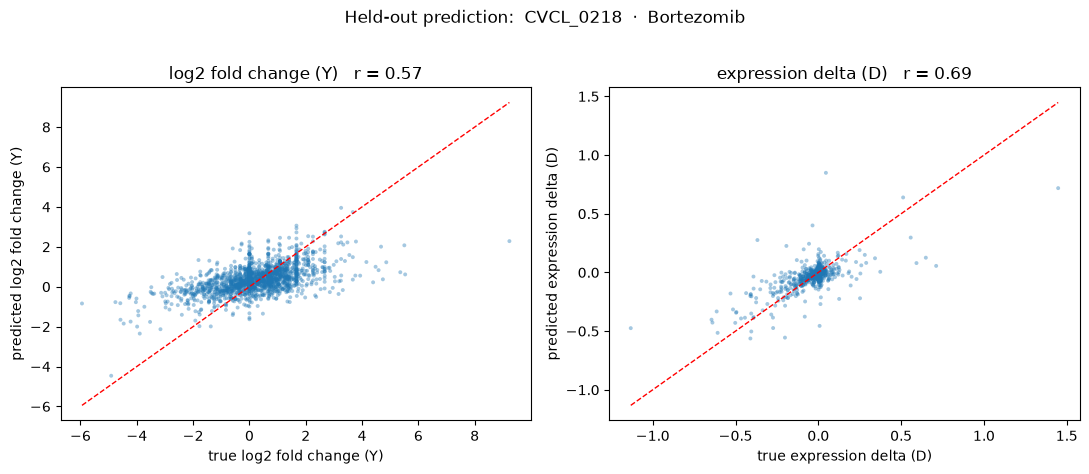

In [11]:
# Predicted vs. true response for the strongest held-out (cell_line, treatment).
i = int(np.argmax(np.abs(np.asarray(data["Y_test"])).sum(axis=1)))
cell, lab = test_keys[i]
y_true, y_pred = np.asarray(data["Y_test"])[i], captured["Y_pred"][i]
d_true, d_pred = np.asarray(data["D_test"])[i], captured["D_pred"][i]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for a, (t, p, name) in zip(ax, [(y_true, y_pred, "log2 fold change (Y)"),
                                (d_true, d_pred, "expression delta (D)")]):
    a.scatter(t, p, s=8, alpha=0.4, edgecolor="none")
    lo, hi = min(t.min(), p.min()), max(t.max(), p.max())
    a.plot([lo, hi], [lo, hi], "r--", lw=1)
    r = np.corrcoef(t, p)[0, 1]
    a.set(xlabel=f"true {name}", ylabel=f"predicted {name}", title=f"{name}   r = {r:.2f}")
fig.suptitle(f"Held-out prediction:  {cell}  ·  {lab.split(chr(39))[1]}", y=1.02)
fig.tight_layout()
plt.show()

## What to try next

- **Your own data.** Swap in any single-cell AnnData with cell-line and treatment
  labels plus DMSO controls, rerun step 3 to build the matrices, and call
  `train_and_evaluate(data=...)`. The held-out pairs it can predict are
  `(cell, treatment)` combinations where the cell and the treatment each appear
  elsewhere in train.
- **More signal.** Switch `DATA_MODE` to `"tahoe100m"`, then raise
  `--cells-per-group` or add cell lines and drugs in
  `scripts/build_example_h5ad.py` — the metrics climb toward the full-data
  numbers as the DE estimates get less noisy.
- **A different slice.** `fetch_de_subset(plate, cell_lines, treatments, panel)`
  reads any slice of the published Tahoe DE data without downloading the whole
  41.8 GB dataset. Remember that the plate fixes the dose.
- **The 6th metric.** Rebuild the dict and pass `compute_discrimination=True`.

**Caveats.** `evaluate_test` is one-shot (re-run the dict-assembly cell to score
again). This notebook demonstrates the data-prep + fit-and-evaluate path; it does
not persist a reusable model — the per-cell ridge re-fits against the training
cells at predict time (`paper_methods.md` §2). Repo:
<https://huggingface.co/tahoebio/Rhaister>.